     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  Year    Month  
0     SAVE10      Instagram     2853.10  2023  2023-01  
1     SAVE10       Referra

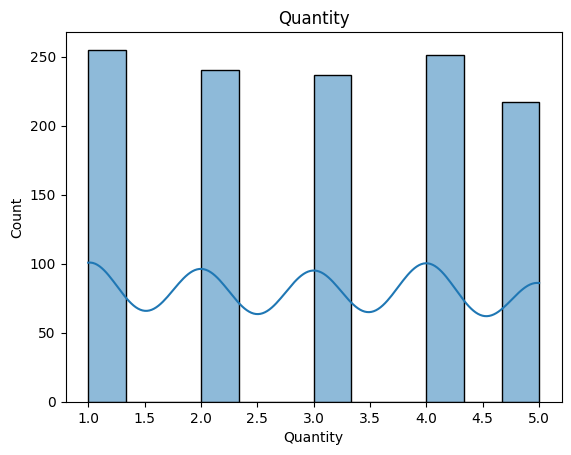

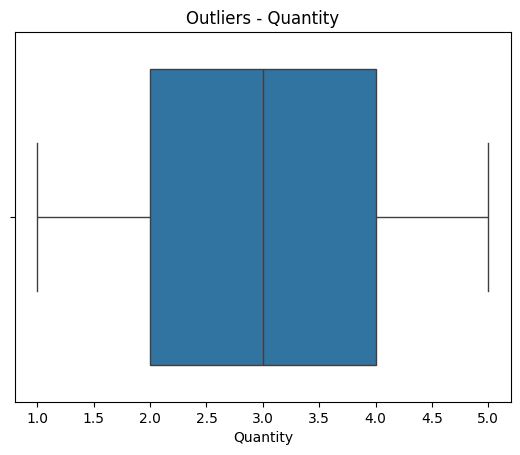

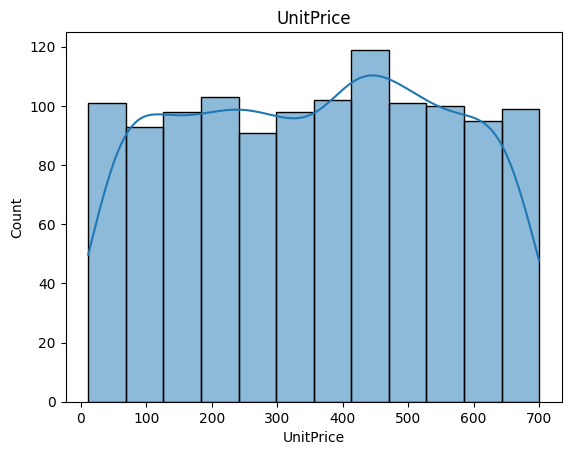

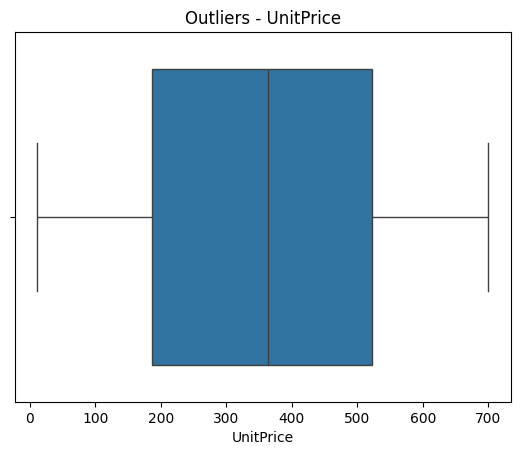

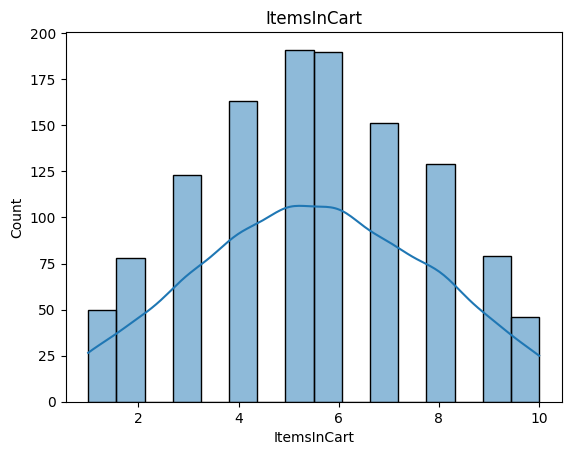

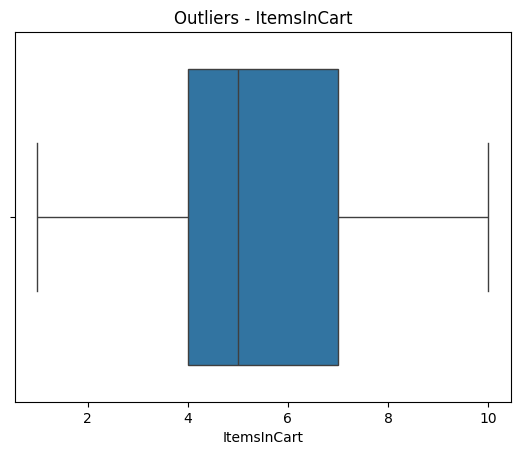

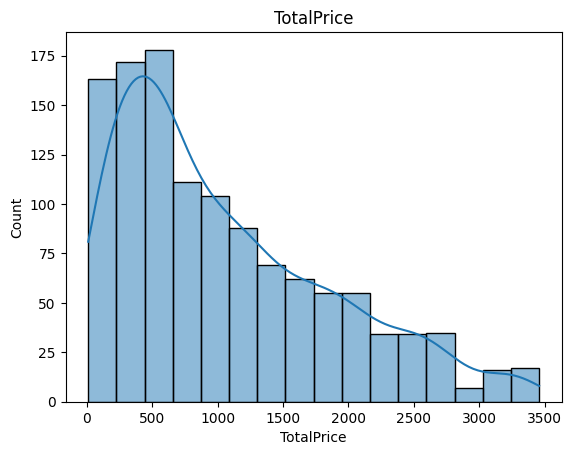

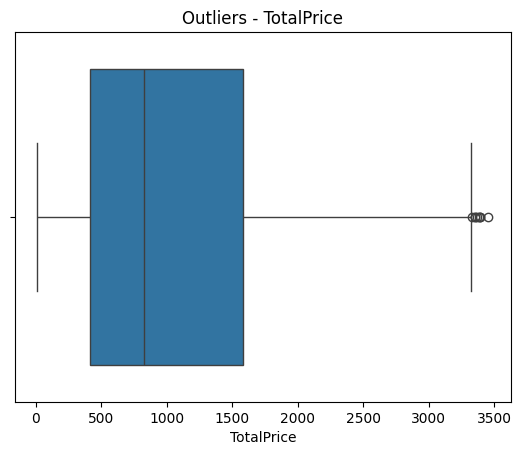

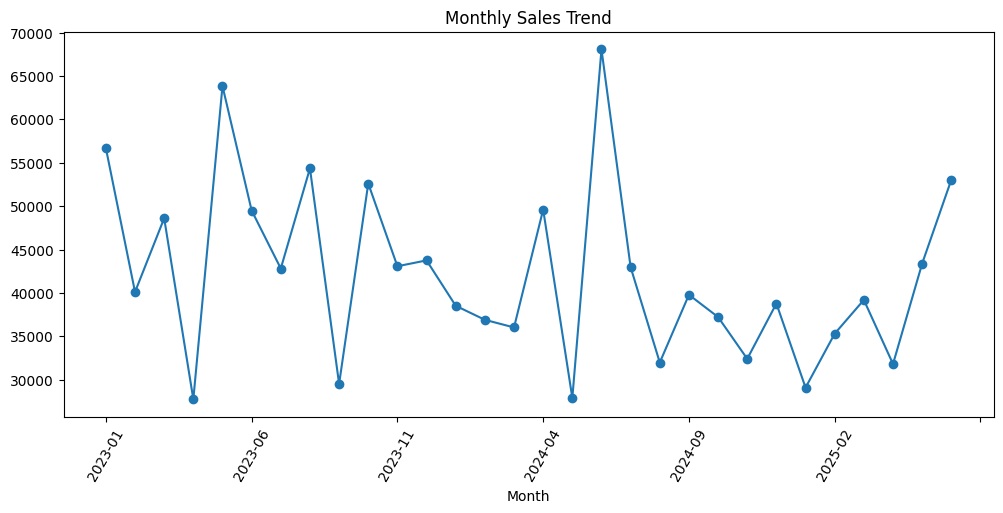


Sales by Product:
 Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


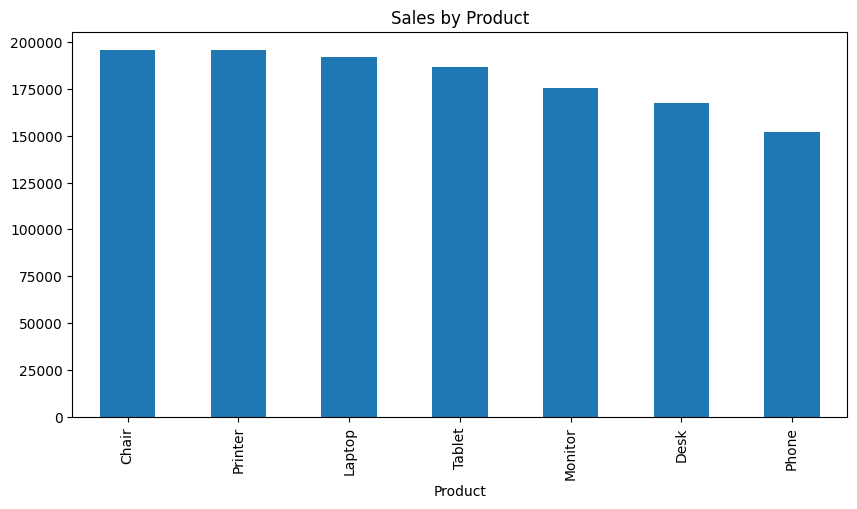


Order Status:
 OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

Payment Method:
 PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


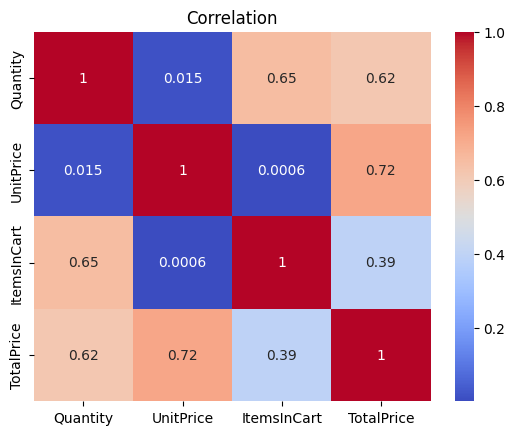


Total Sales: 1264761.96
Average Order Value: 1053.9683
Median Order Value: 823.615
Top Product: Chair


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/content/Dataset for Data Analytics.xlsx")
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.to_period("M").astype(str)

print(df.head())
print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nStatistics:\n", df[["Quantity","UnitPrice","ItemsInCart","TotalPrice"]].describe())
print("\nMedian:\n", df[["Quantity","UnitPrice","ItemsInCart","TotalPrice"]].median())

for c in ["Quantity","UnitPrice","ItemsInCart","TotalPrice"]:
    sns.histplot(df[c], kde=True)
    plt.title(c)
    plt.show()

    sns.boxplot(x=df[c])
    plt.title("Outliers - " + c)
    plt.show()

monthly = df.groupby("Month")["TotalPrice"].sum()
monthly.plot(figsize=(12,5), marker="o", title="Monthly Sales Trend")
plt.xticks(rotation=60)
plt.show()

product = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)
print("\nSales by Product:\n", product)

product.plot(kind="bar", figsize=(10,5), title="Sales by Product")
plt.show()

print("\nOrder Status:\n", df["OrderStatus"].value_counts())
print("\nPayment Method:\n", df["PaymentMethod"].value_counts())

corr = df[["Quantity","UnitPrice","ItemsInCart","TotalPrice"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation")
plt.show()

print("\nTotal Sales:", df["TotalPrice"].sum())
print("Average Order Value:", df["TotalPrice"].mean())
print("Median Order Value:", df["TotalPrice"].median())
print("Top Product:", product.idxmax())
